In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv("/content/CC_data.csv")
print(df.head())

  Male    Age   Debt Married BankCustomer EducationLevel Ethnicity  \
0    b  30.83  0.000       u            g              w         v   
1    a  58.67  4.460       u            g              q         h   
2    a   24.5  0.500       u            g              q         h   
3    b  27.83  1.540       u            g              w         v   
4    b  20.17  5.625       u            g              w         v   

   YearsEmployed PriorDefault Employed  CreditScore DriversLicense Citizen  \
0           1.25            t        t            1              f       g   
1           3.04            t        t            6              f       g   
2           1.50            t        f            0              f       g   
3           3.75            t        t            5              t       g   
4           1.71            t        f            0              f       s   

  ZipCode  Income Approved  
0     202       0        +  
1      43     560        +  
2     280     824      

In [21]:
df.columns

Index(['Male', 'Age', 'Debt', 'Married', 'BankCustomer', 'EducationLevel',
       'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
       'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'Approved'],
      dtype='object')

In [22]:
df.rename(columns={

    'Male': 'Gender',

    'Married': 'MaritalStatus'

}, inplace=True)


In [23]:
df['Gender'] = df['Gender'].replace({

    'a': 'Male',

    'b': 'Female'

})

In [24]:
df['MaritalStatus'] = df['MaritalStatus'].replace({

    'u': 'Single',

    'y': 'Married',

    'l': 'Separated'

})


In [25]:
df['Ethnicity'] = df['Ethnicity'].replace({

    'v': 'White',

    'h': 'Black',

    'bb': 'Asian',

    'j': 'Latino',

    'n': 'Indian',

    'z': 'Other',

    'dd': 'Mixed',

    'ff': 'European',

    'o': 'Unknown'

})


In [26]:
df[['Gender','MaritalStatus','Ethnicity']].head()


,Gender,MaritalStatus,Ethnicity
0,Female,Single,White
1,Male,Single,Black
2,Male,Single,Black
3,Female,Single,White
4,Female,Single,White


In [27]:
df['BankCustomer'] = df['BankCustomer'].replace({

    'g': 'Government',

    'p': 'Private',

    'gg': 'Other'

})

In [28]:
df['EducationLevel'] = df['EducationLevel'].replace({

    'w': 'School',

    'q': 'Graduate',

    'm': 'Masters',

    'r': 'PhD',

    'cc': 'Professional',

    'x': 'Diploma',

    'd': 'Dropout',

    'e': 'Engineering',

    'aa': 'MBA',

    'ff': 'Medical',

    'j': 'Law',

    'k': 'Commerce',

    'i': 'Arts'

})

In [29]:
df[['Gender','MaritalStatus','BankCustomer','EducationLevel','Ethnicity']].head()

,Gender,MaritalStatus,BankCustomer,EducationLevel,Ethnicity
0,Female,Single,Government,School,White
1,Male,Single,Government,Graduate,Black
2,Male,Single,Government,Graduate,Black
3,Female,Single,Government,School,White
4,Female,Single,Government,School,White


In [30]:
df["Approved"].value_counts()

,count
Approved,
-,383
+,307


In [31]:
df['Approved'] = df['Approved'].replace({

    '+':1,

    '-':0

})

In [36]:
df.isnull().sum()

,0
Gender,0
Age,12
Debt,0
MaritalStatus,0
BankCustomer,0
EducationLevel,0
Ethnicity,0
YearsEmployed,0
PriorDefault,0
Employed,0


In [37]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [38]:
df.isnull().sum()

,0
Gender,0
Age,0
Debt,0
MaritalStatus,0
BankCustomer,0
EducationLevel,0
Ethnicity,0
YearsEmployed,0
PriorDefault,0
Employed,0


In [39]:
df['Age'].head()

,Age
0,30.83
1,58.67
2,24.50
3,27.83
4,20.17


In [46]:
df['Age'] = df['Age'].astype(int)

In [47]:
df['Age'].head()

,Age
0,30
1,58
2,24
3,27
4,20


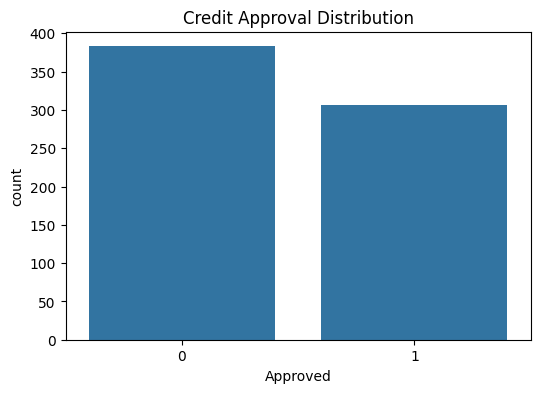

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(x='Approved', data=df)

plt.title("Credit Approval Distribution")

plt.show()


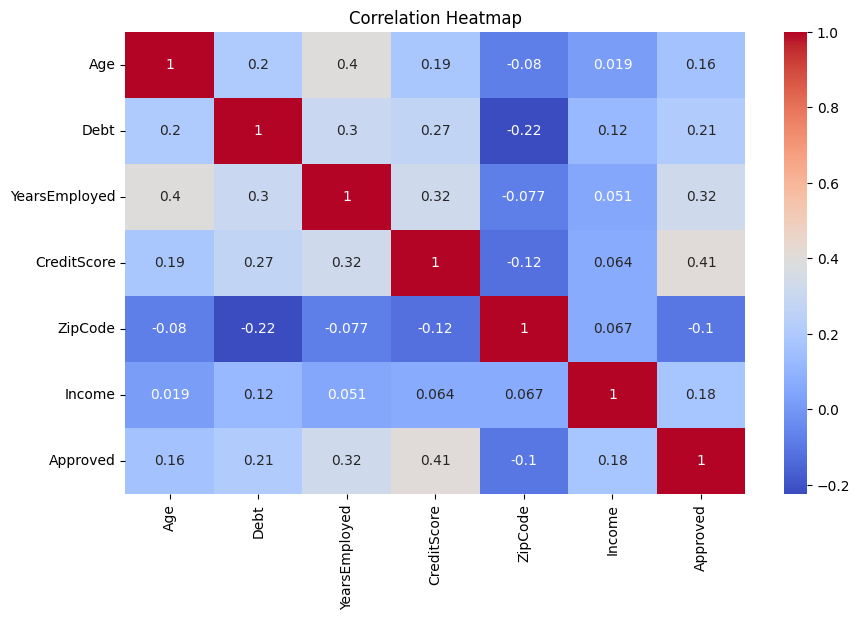

In [35]:
num_cols = ['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'ZipCode', 'Income']

# Replace '?' with NaN and convert to numeric for each column in num_cols
for col in num_cols:
    if df[col].dtype == 'object': # Check if the column is of object type (string)
        df[col] = df[col].replace('?', np.nan).astype(float)

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols + ['Approved']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

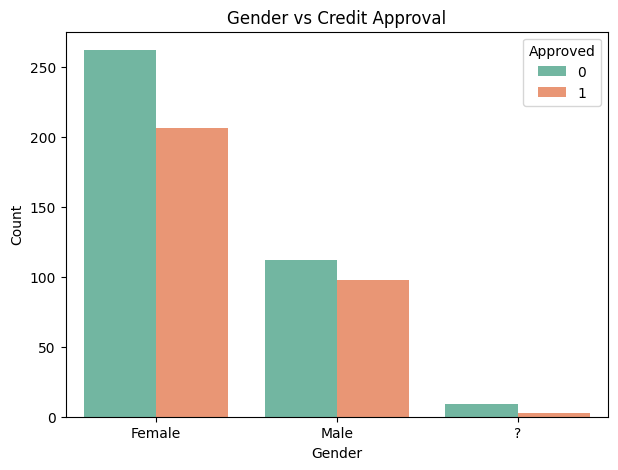

In [48]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Gender', hue='Approved', palette='Set2')

plt.title("Gender vs Credit Approval")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()


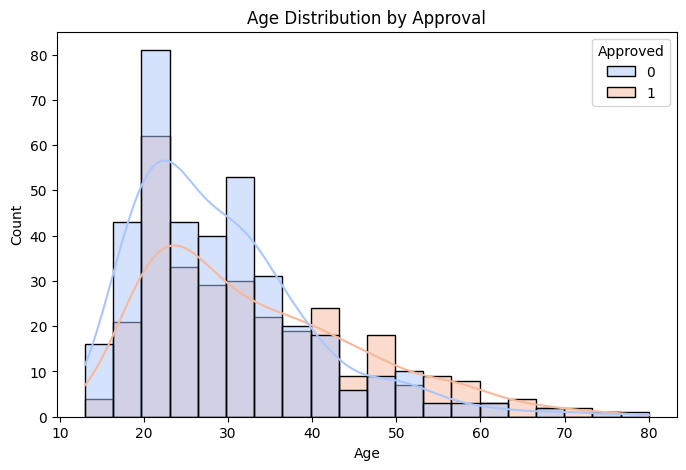

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Age', hue='Approved', bins=20, kde=True, palette='coolwarm')

plt.title("Age Distribution by Approval")

plt.show()


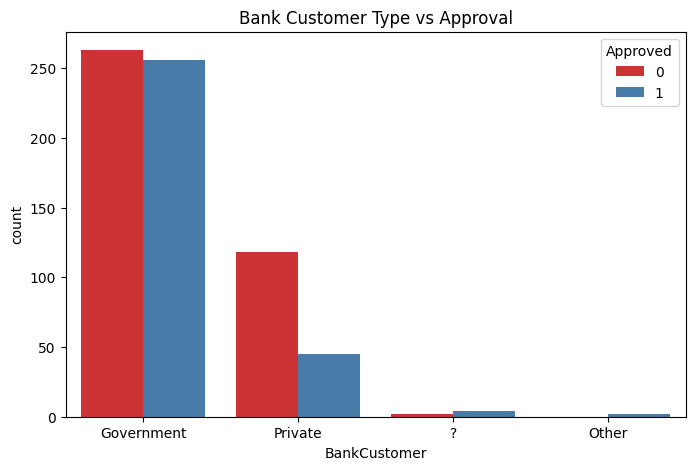

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='BankCustomer', hue='Approved', palette='Set1')

plt.title("Bank Customer Type vs Approval")

plt.show()


In [52]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier


In [56]:
df_model = df[[

    'Age',

    'Gender',

    'Income',

    'Debt',

    'MaritalStatus',

    'EducationLevel',

    'BankCustomer',

    'YearsEmployed',

    'PriorDefault',

    'Employed',

    'CreditScore',

    'Approved'

]]

In [57]:
X = df_model.drop('Approved', axis=1)

y = df_model['Approved']

In [59]:
cat_cols = X.select_dtypes(include='object').columns.tolist()

num_cols = X.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer([

    ('num', Pipeline([

        ('imputer', SimpleImputer(strategy='median')),

        ('scaler', StandardScaler())

    ]), num_cols),

    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)

])

In [60]:
X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


In [62]:
model = Pipeline([

    ('prep', preprocessor),

    ('clf', RandomForestClassifier(

        n_estimators=300,

        max_depth=8,

        random_state=42

    ))

])

In [63]:
model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Income', 'Debt',
                                                   'YearsEmployed',
                                                   'CreditScore']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'MaritalStatus',
                                                   'EducationLevel',
                                                   'BankCustomer',
                                                   'PriorDefault',
                                                   'Employed'])])),
                ('clf',
                 RandomForestClassifier(max_depth=8, n_estimators=300,
                                        random_state=42))])

In [64]:
pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy : 0.8913043478260869
              precision    recall  f1-score   support

           0       0.87      0.95      0.91        77
           1       0.93      0.82      0.87        61

    accuracy                           0.89       138
   macro avg       0.90      0.88      0.89       138
weighted avg       0.89      0.89      0.89       138



In [66]:
import ipywidgets as widgets

from IPython.display import display

import pandas as pd

age = widgets.IntSlider(

    value=30, min=18, max=80, step=1,

    description='Age'

)

income = widgets.IntSlider(

    value=1000, min=0, max=100000, step=500,

    description='Income'

)

debt = widgets.FloatSlider(

    value=2.0, min=0, max=30, step=0.1,

    description='Debt'

)

years = widgets.FloatSlider(

    value=1.0, min=0, max=30, step=0.5,

    description='Experience'

)

credit = widgets.IntSlider(

    value=1, min=0, max=20, step=1,

    description='Credit'

)

gender = widgets.Dropdown(

    options=['Male', 'Female'],

    description='Gender'

)

marital = widgets.Dropdown(

    options=['Single', 'Married', 'Separated'],

    description='Marital'

)

education = widgets.Dropdown(

    options=['School','Graduate','Masters','MBA','Engineering','Diploma'],

    description='Education'

)

bank = widgets.Dropdown(

    options=['Government','Private','Other'],

    description='Bank'

)

prior = widgets.Dropdown(

    options=['t','f'],

    description='Default'

)

employed = widgets.Dropdown(

    options=['t','f'],

    description='Employed'

)

btn = widgets.Button(

    description='Predict',

    button_style='success'

)

out = widgets.Output()

def predict_credit(b):

    with out:

        out.clear_output()

        row = pd.DataFrame([{

            'Age': age.value,

            'Gender': gender.value,

            'Income': income.value,

            'Debt': debt.value,

            'MaritalStatus': marital.value,

            'EducationLevel': education.value,

            'BankCustomer': bank.value,

            'YearsEmployed': years.value,

            'PriorDefault': prior.value,

            'Employed': employed.value,

            'CreditScore': credit.value

        }])

        pred = model.predict(row)[0]

        prob = model.predict_proba(row)[0][1]

        if pred == 1:

            print("✅ Credit Approved")

        else:

            print("❌ Credit Rejected")

        print("Approval Probability:", round(prob*100,2), "%")

btn.on_click(predict_credit)

display(

    age, income, debt, years, credit,

    gender, marital, education, bank,

    prior, employed,

    btn, out

)

IntSlider(value=30, description='Age', max=80, min=18)

IntSlider(value=1000, description='Income', max=100000, step=500)

FloatSlider(value=2.0, description='Debt', max=30.0)

FloatSlider(value=1.0, description='Experience', max=30.0, step=0.5)

IntSlider(value=1, description='Credit', max=20)

...

Dropdown(description='Bank', options=('Government', 'Private', 'Other'), value='Government')

Dropdown(description='Default', options=('t', 'f'), value='t')

Dropdown(description='Employed', options=('t', 'f'), value='t')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()